In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
import pandas as pd
from numpy.random import choice

In [42]:
pip install emcee

Note: you may need to restart the kernel to use updated packages.


In [43]:
pip install pymc

Note: you may need to restart the kernel to use updated packages.


In [2]:
import emcee
import pymc

In [3]:
from scipy import integrate
from scipy.stats import norm
from scipy.stats import cauchy


In [4]:
path = '../solutions/transient.npy'

In [5]:
data = np.load(path)
np.shape(data)
times = []
F = []
sF = []
for i in range(100):
    times = np.append(times,data[i][0])
    F = np.append(F,data[i][1])
    sF = np.append(sF,data[i][2])



<ErrorbarContainer object of 3 artists>

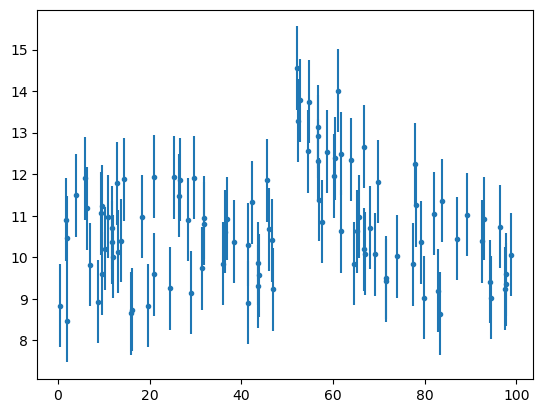

In [9]:
plt.errorbar(times,F,sF,linestyle='',fmt='.')

In [15]:
#data[1] flux, data[2] err on flux

In [10]:
def model(t,b,A,alpha,t0):
    if t<t0: y = b
    else: y = b + A*np.exp(-alpha*(t-t0))
    return y



In [13]:
def Likelihood(b,A,alpha,t0):
    L_scan = []
    for i in range(len(times)):
        L_temp = norm.pdf(times[i], loc=F[i]-model(times[i],b,A,alpha,t0), scale=sF[i]) # gives you the log prob. density; useful!
        L_temp = np.sum(L_temp) # sum over the log pmf of all data points
        L_scan.append(L_temp)
        L_scan = np.array(L_scan)
        return(L_scan)

In [18]:
np.random.seed(0)
N = 200

b = stats.uniform(0,50).rvs(N)
A = stats.uniform(0,50).rvs(N)
t0 = stats.uniform(0,100).rvs(N)
lnalpha = stats.uniform(-5,5).rvs(N) 
alpha = np.exp(lnalpha)